In [1]:
using Distributed
# addprocs(6)
@everywhere using Arpack
@everywhere using WignerSymbols
@everywhere using LinearAlgebra
@everywhere using GenericLinearAlgebra
@everywhere using GenericSchur
@everywhere using SharedArrays
@everywhere using SparseArrays
using BenchmarkTools
using Plots
#using GLM
#using DataFrames
@everywhere push!(LOAD_PATH, ".")
@everywhere include("threej.jl")
@everywhere include("cuba.jl")
@everywhere include("Trans.jl")
@everywhere include("volume.jl")
@everywhere include("ME.jl")

In [11]:
@everywhere jm61=[10 30 30 30 30]
@everywhere jm62=[30 10 30 30 30]
AA1=spzeros(Int((2*jm61[1]+1)*(2*jm61[2]+1)*(2*jm61[3]+1)*(2*jm61[4]+1)*(2*jm61[5]+1)))
sixj1(jm61,AA1)
@everywhere B1=$AA1
AA2=spzeros(Int((2*jm62[1]+1)*(2*jm62[2]+1)*(2*jm62[3]+1)*(2*jm62[4]+1)*(2*jm62[5]+1)))
sixj1(jm62,AA2)
@everywhere B2=$AA2

In [2]:
@everywhere jm61=[30 90 90 90 90]
@everywhere jm62=[90 30 90 90 90]
AA1=spzeros(Int((2*jm61[1]+1)*(2*jm61[2]+1)*(2*jm61[3]+1)*(2*jm61[4]+1)*(2*jm61[5]+1)))
sixj1(jm61,AA1)
@everywhere B1=$AA1
AA2=spzeros(Int((2*jm62[1]+1)*(2*jm62[2]+1)*(2*jm62[3]+1)*(2*jm62[4]+1)*(2*jm62[5]+1)))
sixj1(jm62,AA2)
@everywhere B2=$AA2

In [2]:
resv4=Array{Complex{Float64}}(undef,2000)
for iv in 1:2000
    ls123=([1,2,1,2]*1*(2*iv+1)/2)
    vol1q=2*qas(ls123)*im/4
    (e1,ev)=eigs(vol1q)
    resv4[iv]=sqrt(abs(maximum(real(e1))))/8
    print(iv)
end

┌ Warning: Adjusting nev from 6 to 2
└ @ Arpack ~/.julia/packages/Arpack/FCvNd/src/Arpack.jl:92


1234567891011121314151617181920212223242526272829303132333435

┌ Warning: Adjusting nev from 6 to 4
└ @ Arpack ~/.julia/packages/Arpack/FCvNd/src/Arpack.jl:92


3637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989910010110210310410510610710810911011111211311411511611711811912012112212312412512612712812913013113213313413513613713813914014114214314414514614714814915015115215315415515615715815916016116216316416516616716816917017117217317417517617717817918018118218318418518618718818919019119219319419519619719819920020120220320420520620720820921021121221321421521621721821922022122222322422522622722822923023123223323423523623723823924024124224324424524624724824925025125225325425525625725825926026126226326426526626726826927027127227327427527627727827928028128228328428528628728828929029129229329429529629729829930030130230330430530630730830931031131231331431531631731831932032132232332432532632732832933033133233333433533633733833934034134234334434534634734834935035135235335435535635735835936036136236336436536636736836937037137237337437537637737837938038138238338438538638738838939

In [3]:
print(real(resv4))

[0.5356398536224453, 1.0666747364790872, 1.7116668072116188, 2.452473403188594, 3.2777713437410934, 4.1795812185452235, 5.151855716769249, 6.189797867269342, 7.289478834705319, 8.447602771674395, 9.661352611172662, 10.928283996698474, 12.246249536879931, 13.613343046080535, 15.027857449573025, 16.488252320850723, 17.99312838637662, 19.541207183366577, 21.131314602914273, 22.76236741264222, 24.433362098733532, 26.14336553774635, 27.891507129375597, 29.676972108369817, 31.49899581755692, 33.35685877130027, 35.249882374364695, 37.17742518834936, 39.13887965877208, 41.13366923219099, 43.16124580554327, 45.221087460032415, 47.312696439993026, 49.4355973436978, 51.58933549834988, 53.77347549582791, 55.987599869296886, 58.23130789371858, 60.50421449573655, 62.80594926043291, 65.13615552416206, 67.49448954409904, 69.88061973635884, 72.29422597557037, 74.73499894967662, 77.20263956448503, 79.69685839313932, 82.21737516624773, 84.76391829888988, 87.33622445113407, 89.93403811908188, 92.557111253

In [7]:
resv4=SharedArray{Complex{Float64}}(2000)
ls123=([1,1,1,1]*1*1001 )40
vol1q=2*qas(ls123)*im/4
(e1,ev)=eigs(vol1q)
resv4[1001]=sqrt(maximum(real(e1)))/8

4913.9178382614855

In [26]:
sqrt(2)/12*((2*sqrt(1000))/3^(1/4))^3*3/sqrt(2)/2

13872.638167626059

In [9]:
n6=3
ls123=[1,1,1,1,1,1]*n6
Al=Fai6(ls123)
# print("step1")
vol1q6=im*1/4*(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,3,5,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2)+v123(ls123,Al,3,4,5,6,jm61,jm62,B1,B2)-v123(ls123,Al,4,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))
# print("step2")
(e1,ev)=eigs(vol1q6)
# print("step3")
resv6=sqrt(maximum(real(e1)))/8

1.977210875478067

In [ ]:
n6=22
ls123=[1,1,1,1,1,1]*n6
Al=Fai6(ls123)
# print("step1")
vol1q6=im*1/4*(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,3,5,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2)+v123(ls123,Al,3,4,5,6,jm61,jm62,B1,B2)-v123(ls123,Al,4,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))
# print("step2")
(e1,ev)=eigs(vol1q6)
# print("step3")
resv6=sqrt(maximum(real(e1)))/8

In [ ]:
n6=23
ls123=[1,1,1,1,1,1]*n6
Al=Fai6(ls123)
# print("step1")
vol1q6=im*1/4*(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,3,5,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2)+v123(ls123,Al,3,4,5,6,jm61,jm62,B1,B2)-v123(ls123,Al,4,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))
# print("step2")
(e1,ev)=eigs(vol1q6)
# print("step3")
resv6=sqrt(maximum(real(e1)))/8

In [ ]:
n6=24
ls123=[1,1,1,1,1,1]*n6
Al=Fai6(ls123)
# print("step1")
vol1q6=im*1/4*(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,3,5,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2)+v123(ls123,Al,3,4,5,6,jm61,jm62,B1,B2)-v123(ls123,Al,4,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))
# print("step2")
(e1,ev)=eigs(vol1q6)
# print("step3")
resv6=sqrt(maximum(real(e1)))/8

In [ ]:
n6=25
ls123=[1,1,1,1,1,1]*n6
Al=Fai6(ls123)
# print("step1")
vol1q6=im*1/4*(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,3,5,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2)+v123(ls123,Al,3,4,5,6,jm61,jm62,B1,B2)-v123(ls123,Al,4,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))
# print("step2")
(e1,ev)=eigs(vol1q6)
# print("step3")
resv6=sqrt(maximum(real(e1)))/8

In [ ]:
n6=26
ls123=[1,1,1,1,1,1]*il
Al=Fai6(ls123)
# print("step1")
vol1q6=im*1/4*(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,3,5,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2)+v123(ls123,Al,3,4,5,6,jm61,jm62,B1,B2)-v123(ls123,Al,4,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))
# print("step2")
(e1,ev)=eigs(vol1q6)
# print("step3")
resv6=sqrt(maximum(real(e1)))/8

In [ ]:
n6=27
ls123=[1,1,1,1,1,1]*il
Al=Fai6(ls123)
# print("step1")
vol1q6=im*1/4*(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,3,5,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2)+v123(ls123,Al,3,4,5,6,jm61,jm62,B1,B2)-v123(ls123,Al,4,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))
# print("step2")
(e1,ev)=eigs(vol1q6)
# print("step3")
resv6=sqrt(maximum(real(e1)))/8

In [ ]:
n6=28
ls123=[1,1,1,1,1,1]*il
Al=Fai6(ls123)
# print("step1")
vol1q6=im*1/4*(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,3,5,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2)+v123(ls123,Al,3,4,5,6,jm61,jm62,B1,B2)-v123(ls123,Al,4,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))
# print("step2")
(e1,ev)=eigs(vol1q6)
# print("step3")
resv6=sqrt(maximum(real(e1)))/8

In [ ]:
n6=29
ls123=[1,1,1,1,1,1]*il
Al=Fai6(ls123)
# print("step1")
vol1q6=im*1/4*(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,3,5,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2)+v123(ls123,Al,3,4,5,6,jm61,jm62,B1,B2)-v123(ls123,Al,4,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))
# print("step2")
(e1,ev)=eigs(vol1q6)
# print("step3")
resv6=sqrt(maximum(real(e1)))/8

In [3]:
n6=30
ls123=[1,1,1,1,1,1]*n6
Al=Fai6(ls123)
# print("step1")
vol1q6=im*1/4*(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,3,5,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2)+v123(ls123,Al,3,4,5,6,jm61,jm62,B1,B2)-v123(ls123,Al,4,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))
# print("step2")
(e1,ev)=eigs(vol1q6)
# print("step3")
resv6=sqrt(maximum(real(e1)))/8

58.52184151998605

In [4]:
ls123=[1,1,1,1,1,1]*20
Al=size(Fai6(ls123))

(34481, 6)

In [20]:
size(Al)

(9855, 6)

In [22]:
[4.130762390259768/3.952847075210474 11.428909687380324/11.180339887498949 0 13.159059263773004/12.89864333951443 0 14.968685319568495/14.696938456699069 0 16.85443784287248/16.57181341917655]

1×8 Matrix{Float64}:
 1.04501  1.02223  0.0  1.02019  0.0  1.01849  0.0  1.01705

In [21]:
(13/2)^(3/2)

16.57181341917655

In [10]:
big "100"

LoadError: ParseError:
[90m# Error @ [0;0m]8;;file:///home/eqwaplay/Work/Volume Numerics/julia code/code/In[10]#1:4\[90mIn[10]:1:4[0;0m]8;;\
big[48;2;120;70;70m "100"[0;0m
[90m#  └────┘ ── [0;0m[91mextra tokens after end of expression[0;0m

In [5]:
method("")

LoadError: UndefVarError: `method` not defined

In [6]:
typeof("100")

String

In [13]:
ls123=[big"1",big"1",big"1",big"1"]*big"500"
Al=Fai4([big"1",big"1",big"1",big"1"]*big"500")
vol1q=big"2"*qa(ls123)

1001×1001 Matrix{BigFloat}:
 0.0          -1.15701e+06   0.0          …   0.0         0.0
 1.15701e+06   0.0          -2.06972e+06      0.0         0.0
 0.0           2.06972e+06   0.0              0.0         0.0
 0.0           0.0           3.04862e+06      0.0         0.0
 0.0           0.0           0.0              0.0         0.0
 0.0           0.0           0.0          …   0.0         0.0
 0.0           0.0           0.0              0.0         0.0
 0.0           0.0           0.0              0.0         0.0
 0.0           0.0           0.0              0.0         0.0
 0.0           0.0           0.0              0.0         0.0
 0.0           0.0           0.0          …   0.0         0.0
 0.0           0.0           0.0              0.0         0.0
 0.0           0.0           0.0              0.0         0.0
 ⋮                                        ⋱               ⋮
 0.0           0.0           0.0              0.0         0.0
 0.0           0.0           0.0          … 

In [14]:
(e1,ev)=eigen(vol1q)

LoadError: InterruptException:

In [12]:
sqrt(maximum(imag(e1))/4)/8

155.6839375453149129361405739266880386133081311364413363746222870514436099938672

In [11]:
minimum(abs.(imag(e1)))

0.0

In [108]:
ls123=[1,1,1,1]*100
Al=Fai4([1,1,1,1]*100)
vol1q=2*qa(ls123)

201×201 Matrix{Float64}:
     0.0  -46649.9       0.0        …   0.0            0.0             0.0
 46649.9       0.0  -83443.7            0.0            0.0             0.0
     0.0   83443.7       0.0            0.0            0.0             0.0
     0.0       0.0       1.22895e5      0.0            0.0             0.0
     0.0       0.0       0.0            0.0            0.0             0.0
     0.0       0.0       0.0        …   0.0            0.0             0.0
     0.0       0.0       0.0            0.0            0.0             0.0
     0.0       0.0       0.0            0.0            0.0             0.0
     0.0       0.0       0.0            0.0            0.0             0.0
     0.0       0.0       0.0            0.0            0.0             0.0
     0.0       0.0       0.0        …   0.0            0.0             0.0
     0.0       0.0       0.0            0.0            0.0             0.0
     0.0       0.0       0.0            0.0            0.0             0.0


In [106]:
sqrt(maximum(vol1q)/4)/8

110.49690740802682369046234882183448889396246081788868555753954973901195183114

In [32]:
(e1,ev)=eigen(vol1q)

LoadError: UndefVarError: `vol1q` not defined

In [118]:
sqrt(maximum(abs.(e1))/4)/8

5.345774911695022

In [61]:
sqrt(maximum(imag(e1)))/8

311.36787509062987

In [ ]:
5

In [44]:
5^3

125

34481×6 Matrix{Int64}:
 20   0  20   0  20  0
 20   0  20   1  20  0
 20   0  20   2  20  0
 20   0  20   3  20  0
 20   0  20   4  20  0
 20   0  20   5  20  0
 20   0  20   6  20  0
 20   0  20   7  20  0
 20   0  20   8  20  0
 20   0  20   9  20  0
 20   0  20  10  20  0
 20   0  20  11  20  0
 20   0  20  12  20  0
  ⋮                  ⋮
 20  40  56  39  20  0
 20  40  56  40  20  0
 20  40  57  37  20  0
 20  40  57  38  20  0
 20  40  57  39  20  0
 20  40  57  40  20  0
 20  40  58  38  20  0
 20  40  58  39  20  0
 20  40  58  40  20  0
 20  40  59  39  20  0
 20  40  59  40  20  0
 20  40  60  40  20  0

In [47]:
vol1q=im*1/4*(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,3,5,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2)+v123(ls123,Al,3,4,5,6,jm61,jm62,B1,B2)-v123(ls123,Al,4,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))

In [ ]:
(e1,ev)=eigen(vol1q)

Eigen{ComplexF64, Float64, Matrix{ComplexF64}, Vector{Float64}}
values:
4641-element Vector{Float64}:
 -8359.678505106933
 -7778.969474545914
 -7778.969474545914
 -7778.969474545914
 -7225.175765399078
 -7225.175765399076
 -7225.175765399076
 -7213.502031247348
 -7213.502031247348
 -7213.502031247348
 -6698.784664709665
 -6685.960189460638
 -6685.960189460636
     ⋮
  6685.960189460637
  6698.784664709663
  7213.502031247349
  7213.502031247349
  7213.502031247349
  7225.175765399077
  7225.175765399077
  7225.175765399077
  7778.969474545915
  7778.969474545915
  7778.969474545915
  8359.678505106933
vectors:
4641×4641 Matrix{ComplexF64}:
 -1.71416e-9-1.81443e-9im  …    1.71416e-9-1.81443e-9im
 -5.78643e-9+2.60925e-9im       5.78643e-9+2.60925e-9im
  2.60162e-9+1.70705e-8im      -2.60162e-9+1.70705e-8im
  4.08039e-8+5.98456e-9im      -4.08039e-8+5.98456e-9im
  3.77591e-8-7.89472e-8im      -3.77591e-8-7.89472e-8im
 -1.20724e-7-1.12828e-7im  …    1.20724e-7-1.12828e-7im
 -2.42817e-7+1.3

In [ ]:
sqrt(maximum(e1))/8

11.428909687380324

In [ ]:
10^(3/2)

11.180339887498949

In [18]:
maximum(abs.(im/4*v123New(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)-adjoint(im/4*v123New(ls123,Al,1,2,3,6,jm61,jm62,B1,B2))))

0.0

In [17]:
maximum(abs.(im/4*v123New(ls123,Al,1,2,4,6,jm61,jm62,B1,B2)-adjoint(im/4*v123New(ls123,Al,1,2,4,6,jm61,jm62,B1,B2))))

0.0

In [19]:
maximum(abs.(im/4*v123New(ls123,Al,1,3,4,6,jm61,jm62,B1,B2)-adjoint(im/4*v123New(ls123,Al,1,3,4,6,jm61,jm62,B1,B2))))

0.0

In [20]:
maximum(abs.(im/4*v123New(ls123,Al,2,3,4,6,jm61,jm62,B1,B2)-adjoint(im/4*v123New(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))))

0.0

In [7]:
vol1q-adjoint(vol1q)

4641×4641 Matrix{ComplexF64}:
 0.0+0.0im  -0.0+0.0im   0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im   0.0+0.0im  -0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im   0.0+0.0im   0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im   0.0+0.0im   0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im   0.0+0.0im   0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im   0.0+0.0im   0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im   0.0+0.0im   0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im   0.0+0.0im   0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im   0.0+0.0im   0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im   0.0+0.0im   0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im   0.0+0.0im   0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im   0.0+0.0im   0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im   0.0+0.0im   0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
    ⋮   

In [6]:
maximum(abs.(vol1q-adjoint(vol1q)))

83.23821841930328

In [104]:
sqrt(maximum(real(vol1q)))/8

4.974408308856577

In [115]:
(e1,ev)=eigen(vol1q)

Eigen{ComplexF64, ComplexF64, Matrix{ComplexF64}, Vector{ComplexF64}}
values:
4641-element Vector{ComplexF64}:
  -21.02913900429636 + 1.2766838086384304e-14im
 -20.680527580162433 - 8.711344114038742im
   -20.6805275801622 + 8.71134411403833im
  -19.19438986216899 + 39.915142860177994im
 -19.194389862168954 - 39.91514286017792im
 -15.224475094269934 + 82.68996495749191im
  -15.22447509426984 - 82.6899649574912im
  -14.97899093838182 - 139.70092497039698im
 -14.978990938381388 + 139.70092497039693im
 -14.880066508786062 + 47.49873968307222im
 -14.880066508785802 - 47.498739683071875im
 -14.744289321827507 - 17.017633467663583im
 -14.744289321827408 + 17.017633467663103im
                     ⋮
  19.461813802257144 - 330.68081560899026im
  19.565817528656638 - 58.96660395147956im
   19.56581752865698 + 58.966603951480025im
  19.752923279335235 + 78.94729256061306im
   19.75292327933545 - 78.94729256061196im
  31.977823752235693 - 193.4935000616457im
   31.97782375223614 + 193.49350006164

In [43]:
maximum(real(e1))

150.3964941739787

In [21]:
vol1q-(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,3,5,6,jm61,jm62,B1,B2)+v123(ls123,Al,1,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2)+v123(ls123,Al,3,4,5,6,jm61,jm62,B1,B2)-v123(ls123,Al,4,5,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))

LoadError: UndefVarError: `vol1q` not defined

In [22]:
v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2)

1105×1105 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
    ⋮                             ⋱                        
 0.0+0.0im  0

In [23]:
maximum(real(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)-(-v123(ls123,Al,1,2,4,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,5,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,2,6,6,jm61,jm62,B1,B2))))

2.8421709430404007e-13

In [30]:
maximum(real(v123New(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)-(-v123New(ls123,Al,1,2,4,6,jm61,jm62,B1,B2)-v123New(ls123,Al,1,2,5,6,jm61,jm62,B1,B2)-v123New(ls123,Al,1,2,6,6,jm61,jm62,B1,B2))))

821.9984407117254

In [31]:
maximum(real(v123New(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)-(-v123New(ls123,Al,1,2,4,6,jm61,jm62,B1,B2)-v123New(ls123,Al,2,4,5,6,jm61,jm62,B1,B2)+v123New(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))))

782.8339206807667

In [25]:
maximum(real(v123(ls123,Al,2,4,5,6,jm61,jm62,B1,B2)-(-v123(ls123,Al,1,2,4,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,4,6,6,jm61,jm62,B1,B2)+v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2))))

8.526512829121202e-13

In [26]:
maximum(real(v123(ls123,Al,2,3,5,6,jm61,jm62,B1,B2)-(-v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,6,6,jm61,jm62,B1,B2))))

8.810729923425242e-13

In [27]:
maximum(real(v123(ls123,Al,1,3,6,6,jm61,jm62,B1,B2)-(v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,3,4,6,jm61,jm62,B1,B2)-v123(ls123,Al,1,3,5,6,jm61,jm62,B1,B2))))

8.810729923425242e-13

In [29]:
maximum(real(v123(ls123,Al,2,3,6,6,jm61,jm62,B1,B2)-(-v123(ls123,Al,1,2,3,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,4,6,jm61,jm62,B1,B2)-v123(ls123,Al,2,3,5,6,jm61,jm62,B1,B2))))

8.810729923425242e-13

In [11]:
-v123(ls123,Al,1,2,3,4,jm61,jm62,B1,B2)

5×5 Matrix{ComplexF64}:
     -0.0-0.0im      -0.0-0.0im  1.73205+0.0im     -0.0-0.0im  -0.0-0.0im
     -0.0-0.0im      -0.0-0.0im     -0.0-0.0im  1.73205+0.0im  -0.0-0.0im
 -1.73205-0.0im      -0.0-0.0im     -0.0-0.0im     -0.0-0.0im  -0.0-0.0im
     -0.0-0.0im  -1.73205-0.0im     -0.0-0.0im     -0.0-0.0im  -0.0-0.0im
     -0.0-0.0im      -0.0-0.0im     -0.0-0.0im     -0.0-0.0im  -0.0-0.0im

In [3]:
list1=[Diagonal([i for i in 1:10]),Diagonal([i for i in 1:10]),Diagonal([i for i in 1:10]),Diagonal([i for i in 1:10]),Diagonal([i for i in 1:10])]

5-element Vector{Diagonal{Int64, Vector{Int64}}}:
 [1 0 … 0 0; 0 2 … 0 0; … ; 0 0 … 9 0; 0 0 … 0 10]
 [1 0 … 0 0; 0 2 … 0 0; … ; 0 0 … 9 0; 0 0 … 0 10]
 [1 0 … 0 0; 0 2 … 0 0; … ; 0 0 … 9 0; 0 0 … 0 10]
 [1 0 … 0 0; 0 2 … 0 0; … ; 0 0 … 9 0; 0 0 … 0 10]
 [1 0 … 0 0; 0 2 … 0 0; … ; 0 0 … 9 0; 0 0 … 0 10]

In [5]:
list2=[i for i in 1:10]

10-element Vector{Int64}:
  1
  2
  3
  4
  5
  6
  7
  8
  9
 10

In [6]:
list2[1]=Diagonal([i for i in 1:10])

LoadError: MethodError: [0mCannot `convert` an object of type [92mDiagonal{Int64, Vector{Int64}}[39m[0m to an object of type [91mInt64[39m

[0mClosest candidates are:
[0m  convert(::Type{T}, [91m::T[39m) where T
[0m[90m   @[39m [90mBase[39m [90m[4mBase.jl:84[24m[39m
[0m  convert(::Type{T}, [91m::Number[39m) where T<:Number
[0m[90m   @[39m [90mBase[39m [90m[4mnumber.jl:7[24m[39m
[0m  convert(::Type{<:Integer}, [91m::RationalRoots.RationalRoot[39m)
[0m[90m   @[39m [33mRationalRoots[39m [90m~/.julia/packages/RationalRoots/16tCq/src/[39m[90m[4mRationalRoots.jl:116[24m[39m
[0m  ...


In [7]:
append!(Diagonal([i for i in 1:10]),list1)

LoadError: MethodError: no method matching append!(::Diagonal{Int64, Vector{Int64}}, ::Vector{Diagonal{Int64, Vector{Int64}}})

[0mClosest candidates are:
[0m  append!([91m::Plots.Series[39m, ::Any...)
[0m[90m   @[39m [36mPlots[39m [90m~/.julia/packages/Plots/ju9dp/src/[39m[90m[4mutils.jl:732[24m[39m
[0m  append!([91m::BitVector[39m, ::Any)
[0m[90m   @[39m [90mBase[39m [90m[4mbitarray.jl:786[24m[39m
[0m  append!([91m::Vector[39m, ::AbstractVector)
[0m[90m   @[39m [90mBase[39m [90m[4marray.jl:1179[24m[39m
[0m  ...


In [23]:
using JLD

LoadError: ArgumentError: Package JLD not found in current path:
- Run `import Pkg; Pkg.add("JLD")` to install the JLD package.


# Initialization

In [2]:
@everywhere jm61=[20 60 60 60 60]
@everywhere jm62=[60 20 60 60 60]
AA1=spzeros(Int((2*jm61[1]+1)*(2*jm61[2]+1)*(2*jm61[3]+1)*(2*jm61[4]+1)*(2*jm61[5]+1)))
sixj1(jm61,AA1)
@everywhere B1=$AA1

In [2]:
@everywhere jm61=[10 30 30 30 30]
@everywhere jm62=[30 10 30 30 30]
AA1=spzeros(Int((2*jm61[1]+1)*(2*jm61[2]+1)*(2*jm61[3]+1)*(2*jm61[4]+1)*(2*jm61[5]+1)))
sixj1(jm61,AA1)
@everywhere B1=$AA1

In [3]:
AA2=spzeros(Int((2*jm62[1]+1)*(2*jm62[2]+1)*(2*jm62[3]+1)*(2*jm62[4]+1)*(2*jm62[5]+1)))
sixj1(jm62,AA2)
@everywhere B2=$AA2

# Performance

In [4]:
@everywhere function e123(i)
    ae=i
    alist=[]
    if ae == 0
        alist=[0]
    end
    while ae!=0
        append!(alist,rem(ae,2))
        ae=fld(ae,2)
    end
    return alist
end

In [33]:
n1=0
@sync @distributed for i in 1:20
    j=i/2*[1 1 1 1 1 1]
    A1=Fai6(j)
    ##################################################################
    vol123=v123(j,A1,1,2,3,6,jm61,jm62,B1,B2)
    vol135=v123(j,A1,1,3,5,6,jm61,jm62,B1,B2)
    vol156=v123(j,A1,1,5,6,6,jm61,jm62,B1,B2)
    vol126=v123(j,A1,1,2,6,6,jm61,jm62,B1,B2)
    vol346=v123(j,A1,3,4,5,6,jm61,jm62,B1,B2)
    vol456=v123(j,A1,4,5,6,6,jm61,jm62,B1,B2)
    vol246=v123(j,A1,2,4,6,6,jm61,jm62,B1,B2)
    vol234=v123(j,A1,2,3,4,6,jm61,jm62,B1,B2)
    vol136=v123(j,A1,1,3,6,6,jm61,jm62,B1,B2)
    ##################################################################
    vol136=v123(j,A1,1,3,6,6,jm61,jm62,B1,B2)
    vol236=v123(j,A1,2,3,6,6,jm61,jm62,B1,B2)
    vol346=v123(j,A1,3,4,6,6,jm61,jm62,B1,B2)
    vol356=v123(j,A1,3,5,6,6,jm61,jm62,B1,B2)
    ##################################################################
    vol125=v123(j,A1,1,2,5,6,jm61,jm62,B1,B2)
    vol235=v123(j,A1,2,3,5,6,jm61,jm62,B1,B2)
    vol245=v123(j,A1,2,4,5,6,jm61,jm62,B1,B2)
    vol256=v123(j,A1,2,5,6,6,jm61,jm62,B1,B2)
    ##################################################################
    vol124=v123(j,A1,1,2,4,6,jm61,jm62,B1,B2)
    vol134=v123(j,A1,1,3,4,6,jm61,jm62,B1,B2)
    vol145=v123(j,A1,1,4,5,6,jm61,jm62,B1,B2)
    vol156=v123(j,A1,1,5,6,6,jm61,jm62,B1,B2)
    ##################################################################
    max1=0
    maxi=[]
    array1=zeros((size(A1)[1],size(A1)[1]))
    for ij1 in 1:2^12
        ijlist=zeros(12)
        order=e123(ij1)
        for i1 in 1:size(order)[1]
            ijlist[i1]=order[i1]
        end
        for i1 in 1:12
            if ijlist[i1]==0
                ijlist[i1]=-1
            end
        end
        vol1q=vol123.+vol123.+vol156.+vol126.-vol346.+vol456.+vol246.+vol234.+(vol136.*ijlist[1]).+(vol236.*ijlist[2]).+(vol346.*ijlist[3]).+(vol356.*ijlist[4]).+(vol125.*ijlist[5]).+(vol235.*ijlist[6]).+(vol245.*ijlist[7]).+(vol256.*ijlist[8]).+(vol124.*ijlist[9]).+(vol134.*ijlist[10]).+(vol145.*ijlist[11]).+(vol156.*ijlist[12])
        array1[:,:].=vol1q[:,:]
        m1=maximum(transpose(sqrt.(abs.(eigvals(array1))/4)))
        if m1>=max1
            max1=m1
            maxi=order
        end
    end
    Am[i]=max1
    println(i,maxi)
end
print(Am)

LoadError: [91mInterruptException:[39m

In [40]:
at1=Array{SparseMatrixCSC{ComplexF64,Int64}}(undef,10)
at1[1]=sparse([0])
at1

10-element Vector{SparseMatrixCSC{ComplexF64, Int64}}:
    
     ⋅    
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef

In [7]:
j=[3 3 3 3]
A1=Fai4(j)
maximum(abs.(qa(j)-v123(j,A1,1,2,3,4,jm61,jm62,B1,B2)))

1.0658141036401503e-14

In [7]:
j=[3 3 3 3]
A1=Fai4(j)
v123(j,A1,1,2,3,4,jm61,jm62,B1,B2)

7×7 Matrix{ComplexF64}:
     0.0+0.0im  -27.7128+0.0im  …       0.0+0.0im       0.0+0.0im
 27.7128-0.0im       0.0+0.0im          0.0+0.0im       0.0+0.0im
     0.0+0.0im   46.4758-0.0im          0.0+0.0im       0.0+0.0im
     0.0+0.0im       0.0+0.0im          0.0+0.0im       0.0+0.0im
     0.0+0.0im       0.0+0.0im     -60.3023+0.0im       0.0+0.0im
     0.0+0.0im       0.0+0.0im  …       0.0+0.0im  -39.1361+0.0im
     0.0+0.0im       0.0+0.0im      39.1361-0.0im       0.0+0.0im

In [8]:
j=[3 3 3 3]
A1=Fai4(j)
v123(j,A1,1,2,4,4,jm61,jm62,B1,B2)

7×7 Matrix{ComplexF64}:
      0.0+0.0im   27.7128-0.0im  …       0.0+0.0im      0.0+0.0im
 -27.7128-0.0im       0.0+0.0im          0.0+0.0im      0.0+0.0im
      0.0+0.0im  -46.4758-0.0im          0.0+0.0im      0.0+0.0im
      0.0+0.0im       0.0+0.0im          0.0+0.0im      0.0+0.0im
      0.0+0.0im       0.0+0.0im      60.3023-0.0im      0.0+0.0im
      0.0+0.0im       0.0+0.0im  …       0.0+0.0im  39.1361-0.0im
      0.0+0.0im       0.0+0.0im     -39.1361-0.0im      0.0+0.0im

In [9]:
j=[3 3 3 3]
A1=Fai4(j)
v123(j,A1,1,3,4,4,jm61,jm62,B1,B2)

7×7 Matrix{ComplexF64}:
     0.0+0.0im  -27.7128+0.0im  …       0.0+0.0im       0.0+0.0im
 27.7128+0.0im       0.0+0.0im          0.0+0.0im       0.0+0.0im
     0.0+0.0im   46.4758+0.0im          0.0+0.0im       0.0+0.0im
     0.0+0.0im       0.0+0.0im          0.0+0.0im       0.0+0.0im
     0.0+0.0im       0.0+0.0im     -60.3023+0.0im       0.0+0.0im
     0.0+0.0im       0.0+0.0im  …       0.0+0.0im  -39.1361+0.0im
     0.0+0.0im       0.0+0.0im      39.1361-0.0im       0.0+0.0im

In [10]:
j=[3 3 3 3]
A1=Fai4(j)
v123(j,A1,2,3,4,4,jm61,jm62,B1,B2)

7×7 Matrix{ComplexF64}:
      0.0+0.0im   27.7128+0.0im  …       0.0+0.0im      0.0+0.0im
 -27.7128+0.0im       0.0+0.0im          0.0+0.0im      0.0+0.0im
      0.0+0.0im  -46.4758-0.0im          0.0+0.0im      0.0+0.0im
      0.0+0.0im       0.0+0.0im          0.0+0.0im      0.0+0.0im
      0.0+0.0im       0.0+0.0im      60.3023+0.0im      0.0+0.0im
      0.0+0.0im       0.0+0.0im  …       0.0+0.0im  39.1361+0.0im
      0.0+0.0im       0.0+0.0im     -39.1361+0.0im      0.0+0.0im

In [9]:
j=[3 2 3 4 3 3]
A1=Fai6(j)
maximum(abs.(v123(j,A1,1,2,6,6,jm61,jm62,B1,B2)+v123(j,A1,1,2,3,6,jm61,jm62,B1,B2)+v123(j,A1,1,2,4,6,jm61,jm62,B1,B2)+v123(j,A1,1,2,5,6,jm61,jm62,B1,B2)))

3.907985046680551e-14

In [17]:
j=[3 3 3 3 3 3]
A1=Fai6(j)
maximum(abs.(v123(j,A1,1,3,6,6,jm61,jm62,B1,B2)-v123(j,A1,1,2,3,6,jm61,jm62,B1,B2)+v123(j,A1,1,3,4,6,jm61,jm62,B1,B2)+v123(j,A1,1,3,5,6,jm61,jm62,B1,B2)))

9.592326932761353e-14

In [18]:
j=[3 3 3 3 3 3]
A1=Fai6(j)
maximum(abs.(v123(j,A1,1,4,6,6,jm61,jm62,B1,B2)-v123(j,A1,1,2,4,6,jm61,jm62,B1,B2)-v123(j,A1,1,3,4,6,jm61,jm62,B1,B2)+v123(j,A1,1,4,5,6,jm61,jm62,B1,B2)))

7.105427357601002e-14

In [19]:
j=[3 3 3 3 3 3]
A1=Fai6(j)
maximum(abs.(v123(j,A1,3,4,6,6,jm61,jm62,B1,B2)+v123(j,A1,1,3,4,6,jm61,jm62,B1,B2)+v123(j,A1,2,3,4,6,jm61,jm62,B1,B2)+v123(j,A1,3,4,5,6,jm61,jm62,B1,B2)))

7.815970093361102e-14

In [6]:
@everywhere n1=0
Am=zeros(30)
jcap=5
at1=Array{SparseMatrixCSC{ComplexF64,Int64}}(undef,(2*jcap+1)^5)
for i in 1:size(at1)[1]
    at1[i]=sparse([0])
end
jt1=0
for jj in 0:(2*jcap+1)^5-1
    j1=rem(jj,(2*jcap+1))
    j2=rem(fld(jj,(2*jcap+1)),(2*jcap+1))
    j3=rem(fld(fld(jj,(2*jcap+1)),(2*jcap+1)),(2*jcap+1))
    j4=rem(fld(fld(fld(jj,(2*jcap+1)),(2*jcap+1)),(2*jcap+1)),(2*jcap+1))
    j5=rem(fld(fld(fld(fld(jj,(2*jcap+1)),(2*jcap+1)),(2*jcap+1)),(2*jcap+1)),(2*jcap+1))
    if j5!=jt1
        println(j5)
    end
    j=[j1 j2 j3 j4 j5]/2
    A1=Fai5(j)
    vol1q=v123(j,A1,1,2,3,5,jm61,jm62,B1,B2)+v123(j,A1,1,3,4,5,jm61,jm62,B1,B2)+v123(j,A1,1,4,5,5,jm61,jm62,B1,B2)-v123(j,A1,1,2,5,5,jm61,jm62,B1,B2)-v123(j,A1,2,3,4,5,jm61,jm62,B1,B2)-v123(j,A1,3,4,5,5,jm61,jm62,B1,B2)-v123(j,A1,2,4,5,5,jm61,jm62,B1,B2)-v123(j,A1,2,3,5,5,jm61,jm62,B1,B2)
    at1[jj+1]=sparse(vol1q)
    jt1=j5
end

1
2
3
4
5
6
7
8
9
10


In [14]:
at1

243-element Vector{SparseMatrixCSC{ComplexF64, Int64}}:
 
     ⋅    
 0×0 SparseMatrixCSC{ComplexF64, Int64} with 0 stored entries
 0×0 SparseMatrixCSC{ComplexF64, Int64} with 0 stored entries
 0×0 SparseMatrixCSC{ComplexF64, Int64} with 0 stored entries
 
     ⋅    
 0×0 SparseMatrixCSC{ComplexF64, Int64} with 0 stored entries
 0×0 SparseMatrixCSC{ComplexF64, Int64} with 0 stored entries
 0×0 SparseMatrixCSC{ComplexF64, Int64} with 0 stored entries
 
     ⋅    
 0×0 SparseMatrixCSC{ComplexF64, Int64} with 0 stored entries
 
     ⋅    
 0×0 SparseMatrixCSC{ComplexF64, Int64} with 0 stored entries
 
     ⋅    
 ⋮
 0×0 SparseMatrixCSC{ComplexF64, Int64} with 0 stored entries
 
          ⋅      2.82843+0.0im      -8.0+0.0im           ⋅    
 -2.82843+0.0im          ⋅      -8.48528+0.0im  -12.6491+0.0im
      8.0+0.0im  8.48528+0.0im           ⋅      -4.47214+0.0im
          ⋅      12.6491+0.0im   4.47214+0.0im           ⋅    
 0×0 SparseMatrixCSC{ComplexF64, Int64} with 0 stored entries
 


In [5]:
stime=0
@everywhere n1=0
Am=zeros(30)
jcap=5
jt1=0
for jj in 0:(2*jcap+1)^5-1
    j1=rem(jj,(2*jcap+1))
    j2=rem(fld(jj,(2*jcap+1)),(2*jcap+1))
    j3=rem(fld(fld(jj,(2*jcap+1)),(2*jcap+1)),(2*jcap+1))
    j4=rem(fld(fld(fld(jj,(2*jcap+1)),(2*jcap+1)),(2*jcap+1)),(2*jcap+1))
    j5=rem(fld(fld(fld(fld(jj,(2*jcap+1)),(2*jcap+1)),(2*jcap+1)),(2*jcap+1)),(2*jcap+1))
    j=[j1 j2 j3 j4 j5]/2
    A1=Fai5(j)
    if size(A1)[1]>stime
        stime=size(A1)[1]
    end
end
stime

76

In [21]:
vlist=spzeros(141,141*size(at1)[1])
vlist[141,1000]

0.0

In [15]:
size(at1[2])[1]

0

In [19]:
size(at1)[1]

161051

In [7]:
vlist=spzeros(76,76*size(at1)[1])
vlist2=spzeros(76,76)
for i in 1:size(at1)[1]
    if rem(i,1000)==1
        print(i)
    end
        for k in 1:size(at1[i])[1]
#             vlist[j,(i-1)*141+k]=at1[j,k]
#             if (at1[i])[j,k]!=0
            vlist[1:size(at1[i])[1],(i-1)*76+k].=(at1[i])[1:size(at1[i])[1],k]
#             end
            
        end
#     vlist[1:141,((i-1)*141+1):((i-1)*141+141)]=vlist2
end

1100120013001400150016001700180019001100011100112001130011400115001160011700118001190012000121001220012300124001250012600127001280012900130001310013200133001340013500136001370013800139001400014100142001430014400145001460014700148001490015000151001520015300154001550015600157001580015900160001610016200163001640016500166001670016800169001700017100172001730017400175001760017700178001790018000181001820018300184001850018600187001880018900190001910019200193001940019500196001970019800199001100001101001102001103001104001105001106001107001108001109001110001111001112001113001114001115001116001117001118001119001120001121001122001123001124001125001126001127001128001129001130001131001132001133001134001135001136001137001138001139001140001141001142001143001144001145001146001147001148001149001150001151001152001153001154001155001156001157001158001159001160001161001

In [21]:
vlist

76×12239876 SparseMatrixCSC{Float64, Int64} with 3848580 stored entries:
⠈⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠛⠋⠉⠛⠛⠉⠙⠛⠋⠉⠛⠛⠉⠙⠛⠛⠉⠛⠛⠋⠙⠛⠛

In [ ]:
save("./data/volume1.h5","v",vlist)

In [10]:
vlist=load("./data/volume1.h5","v")

LoadError: ArgumentError: No file exists at given path: ./data/volume1.h5

In [ ]:
j=[j1 j2 j3 j4 j5]
aa=Fai5(j)
i=Int(j[1]+j[2]*(2*jcap+1)+j[3]*(2*jcap+1)^2+j[4]*(2*jcap+1)^3+j[5]*(2*jcap+1)^4)
res1=zeros(size(aa)[1],size(aa)[1])
for ki in 1:size(aa)[1]
    for kj in 1:size(aa)[1]
        at1[ki,kj+(i-1)*141]
    end
end

In [52]:
jj=8001
jcap=7
j1=rem(jj,(2*jcap+1))
j2=rem(fld(jj,(2*jcap+1)),(2*jcap+1))
j3=rem(fld(fld(jj,(2*jcap+1)),(2*jcap+1)),(2*jcap+1))
j4=rem(fld(fld(fld(jj,(2*jcap+1)),(2*jcap+1)),(2*jcap+1)),(2*jcap+1))
j5=rem(fld(fld(fld(fld(jj,(2*jcap+1)),(2*jcap+1)),(2*jcap+1)),(2*jcap+1)),(2*jcap+1))
j=[j1 j2 j3 j4 j5]
print(j)
i=Int(j[1]+j[2]*(2*jcap+1)+j[3]*(2*jcap+1)^2+j[4]*(2*jcap+1)^3+j[5]*(2*jcap+1)^4)
i

[6 8 5 2 0]

8001

In [79]:
function Fai5(j)
    l1 = [0 0 0 0 0];
    for i1 in abs(j[2]-j[1]):abs(j[2]+j[1])
        for j1 in abs(j[3]-i1):abs(j[3]+i1)
            if abs(j1-j[4])<=j[5]<=abs(j1+j[4]) && mod((j[5]+j[4]+j1)*2,2)==0
                l1=vcat(l1, [j[1] i1 j1 j[5] 0])
            end
        end
    end
    return l1[2:end,:]
end

j=[1 1 1 1 1]*4
jcap=5
i=Int(j[1]+j[2]*(2*jcap+1)+j[3]*(2*jcap+1)^2+j[4]*(2*jcap+1)^3+j[5]*(2*jcap+1)^4)
fsa=size(Fai5(j/2),1)
resv=zeros(fsa,fsa)
resv.=vlist[1:fsa,((i)*76+1):((i)*76+fsa)]

16×16 Matrix{Float64}:
  0.0     -49.1854  -41.5692  -78.872   …    0.0        0.0        0.0
 49.1854    0.0     -21.2979    0.0          0.0        0.0        0.0
 41.5692   21.2979    0.0     -22.7684       0.0        0.0        0.0
 78.872     0.0      22.7684    0.0          0.0        0.0        0.0
  0.0      24.5927    0.0       0.0          0.0        0.0        0.0
  0.0      42.5958   25.2       0.0     …    0.0        0.0        0.0
  0.0      38.4936   65.0661   17.6363       0.0        0.0        0.0
  0.0       0.0      65.9891   69.5586       0.0        0.0        0.0
  0.0       0.0       0.0      78.872        0.0        0.0        0.0
  0.0       0.0       0.0       0.0        -39.436      0.0        0.0
  0.0       0.0       0.0       0.0     …  -54.4269   -48.7894     0.0
  0.0       0.0       0.0       0.0         -5.63372  -78.5584   -49.2391
  0.0       0.0       0.0       0.0          0.0       -5.14286  -90.2568
  0.0       0.0       0.0       0.0          0.0

In [ ]:
A1=Fai5(j/2)
vol1q=v123(j/2,A1,1,2,3,5,jm61,jm62,B1,B2)+v123(j/2,A1,1,3,4,5,jm61,jm62,B1,B2)+v123(j/2,A1,1,4,5,5,jm61,jm62,B1,B2)-v123(j/2,A1,1,2,5,5,jm61,jm62,B1,B2)-v123(j/2,A1,2,3,4,5,jm61,jm62,B1,B2)-v123(j/2,A1,3,4,5,5,jm61,jm62,B1,B2)-v123(j/2,A1,2,4,5,5,jm61,jm62,B1,B2)-v123(j/2,A1,2,3,5,5,jm61,jm62,B1,B2)

In [8]:
using H5Sparse
A = H5SparseMatrixCSC("./volume1.h5","v", vlist)

MethodError: MethodError: no method matching _checkbuffers(::H5SparseMatrixCSC{Float64, Int64, HDF5.File})
[0mClosest candidates are:
[0m  _checkbuffers([91m::SparseMatrixCSC[39m) at C:\Users\Administrator\AppData\Local\Programs\Julia-1.7.3\share\julia\stdlib\v1.7\SparseArrays\src\sparsematrix.jl:83

In [3]:
using H5Sparse
B = H5SparseMatrixCSC("./volume1.h5", "v")
sparse(B)

76×12239876 SparseMatrixCSC{Float64, Int64} with 3848580 stored entries:
⠈⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠉⠛⠋⠉⠛⠛⠉⠙⠛⠋⠉⠛⠛⠉⠙⠛⠛⠉⠛⠛⠋⠙⠛⠛

In [70]:
h5open("./result_volume.h5", "w") do file
    write(file, "result", at1)
end

LoadError: MethodError: no method matching datatype(::Vector{SparseMatrixCSC{ComplexF64, Int64}})
[0mClosest candidates are:
[0m  datatype([91m::HDF5.Dataset[39m) at C:\Users\Administrator\.julia\packages\HDF5\0iEnL\src\HDF5.jl:989
[0m  datatype([91m::HDF5.Attribute[39m) at C:\Users\Administrator\.julia\packages\HDF5\0iEnL\src\HDF5.jl:991
[0m  datatype([91m::Union{Bool, Float32, Float64, Int16, Int32, Int64, Int8, UInt16, UInt32, UInt64, UInt8, HDF5.Reference}[39m) at C:\Users\Administrator\.julia\packages\HDF5\0iEnL\src\HDF5.jl:994
[0m  ...

In [55]:
Fai5([1 1 1 1 1]*2)

16×5 Matrix{Int64}:
 2  0  2  2  0
 2  1  1  2  0
 2  1  2  2  0
 2  1  3  2  0
 2  2  0  2  0
 2  2  1  2  0
 2  2  2  2  0
 2  2  3  2  0
 2  2  4  2  0
 2  3  1  2  0
 2  3  2  2  0
 2  3  3  2  0
 2  3  4  2  0
 2  4  2  2  0
 2  4  3  2  0
 2  4  4  2  0

In [11]:
at1

10-element Vector{Matrix{Float64}}:
    [1.0 0.0; 0.0 1.0]
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef

In [ ]:
@everywhere n1=0
Am=zeros(30)
@sync @distributed for i in 1:1
    j=i/2*[1 1 1 1 1 1]
    A1=Fai6(j)
    vol1q=v123(j,A1,1,2,3,6,jm61,jm62,B1,B2)+v123(j,A1,1,3,5,6,jm61,jm62,B1,B2)+v123(j,A1,1,5,6,6,jm61,jm62,B1,B2)-v123(j,A1,1,2,6,6,jm61,jm62,B1,B2)+v123(j,A1,3,4,5,6,jm61,jm62,B1,B2)-v123(j,A1,4,5,6,6,jm61,jm62,B1,B2)-v123(j,A1,2,4,6,6,jm61,jm62,B1,B2)-v123(j,A1,2,3,4,6,jm61,jm62,B1,B2)
    (e1,ev)=eigen(vol1q)
    m1=maximum(transpose(sqrt.(abs.(e1)/4)))
    Am[i]=m1
    println(1)
end
print(Am)

In [23]:
Am=SharedArray{Complex{Float64}}(3000)
n1=0
for i in 3000:3000
    j=i/2*[1 1 1 1]
    vol1q=2*qa(j)
    m1=maximum(transpose(sqrt.(abs.(eigvals(vol1q))/4)))
    Am[i]=m1
    println(m1)
end

72102.36659730572


In [1]:
Am=[0.9306048591020997 + 0.0im, 1.8612097182041993 + 0.0im, 2.9789460677644746 + 0.0im, 4.274675338938462 + 0.0im, 5.7314768056560785 + 0.0im, 7.333302028349509 + 0.0im, 9.067228118566282 + 0.0im, 10.923194992741516 + 0.0im, 12.893235036789571 + 0.0im, 14.970848214634735 + 0.0im, 17.150586071390062 + 0.0im, 19.42778258198927 + 0.0im, 21.79837513534647 + 0.0im, 24.258780296033887 + 0.0im, 26.80580400130202 + 0.0im, 29.43657441232235 + 0.0im, 32.148490326108 + 0.0im, 34.93918067141134 + 0.0im, 37.806472136105626 + 0.0im, 40.74836290457949 + 0.0im, 43.76300107793429 + 0.0im, 46.84866674359764 + 0.0im, 50.00375693021184 + 0.0im, 53.226772872549944 + 0.0im, 56.51630914664739 + 0.0im, 59.871044334274444 + 0.0im, 63.28973294932523 + 0.0im, 66.7711984140255 + 0.0im, 70.31432691506743 + 0.0im, 73.91806200235803 + 0.0im, 77.58139981847586 + 0.0im, 81.30338486694156 + 0.0im, 85.08310624331033 + 0.0im, 88.91969426582745 + 0.0im, 92.81231745267331 + 0.0im, 96.7601798011803 + 0.0im, 100.76251833124367 + 0.0im, 104.81860086078078 + 0.0im, 108.92772398575158 + 0.0im, 113.08921124114627 + 0.0im, 117.3024114225821 + 0.0im, 121.56669705089624 + 0.0im, 125.88146296442551 + 0.0im, 130.24612502561644 + 0.0im, 134.66011893029753 + 0.0im, 139.1228991093464 + 0.0im, 143.6339377137355 + 0.0im, 148.19272367497706 + 0.0im, 152.7987618339187 + 0.0im, 157.45157213160732 + 0.0im, 162.15068885666471 + 0.0im, 166.89565994417558 + 0.0im, 171.6860463216572 + 0.0im, 176.52142129810548 + 0.0im, 181.40136999254497 + 0.0im, 186.32548879885022 + 0.0im, 191.29338488393213 + 0.0im, 196.30467571666114 + 0.0im, 201.35898862514387 + 0.0im, 206.45596038019966 + 0.0im, 211.5952368030726 + 0.0im, 216.7764723955942 + 0.0im, 221.99932999117325 + 0.0im, 227.2634804251282 + 0.0im, 232.5686022230017 + 0.0im, 237.91438130561568 + 0.0im, 243.3005107097365 + 0.0im, 248.72669032328437 + 0.0im, 254.19262663415083 + 0.0im, 259.6980324917181 + 0.0im, 265.24262688027846 + 0.0im, 270.82613470359496 + 0.0im, 276.4482865799094 + 0.0im, 282.10881864675565 + 0.0im, 287.80747237498593 + 0.0im, 293.5439943914502 + 0.0im, 299.3181363098284 + 0.0im, 305.12965456913014 + 0.0im, 310.97831027942766 + 0.0im, 316.86386907440493 + 0.0im, 322.7861009703477 + 0.0im, 328.74478023120577 + 0.0im, 334.7396852394109 + 0.0im, 340.77059837212136 + 0.0im, 346.83730588261864 + 0.0im, 352.9395977865729 + 0.0im, 359.07726775292934 + 0.0im, 365.2501129991708 + 0.0im, 371.4579341907469 + 0.0im, 377.70053534443394 + 0.0im, 383.977723735465 + 0.0im, 390.289309808202 + 0.0im, 396.6351070902212 + 0.0im, 403.01493210961024 + 0.0im, 409.4286043153405 + 0.0im, 415.8759460005768 + 0.0im, 422.35678222876317 + 0.0im, 428.8709407623815 + 0.0im, 435.4182519942433 + 0.0im, 441.99854888120854 + 0.0im]

100-element Array{Complex{Float64},1}:
 0.9306048591020997 + 0.0im
 1.8612097182041993 + 0.0im
 2.9789460677644746 + 0.0im
  4.274675338938462 + 0.0im
 5.7314768056560785 + 0.0im
  7.333302028349509 + 0.0im
  9.067228118566282 + 0.0im
 10.923194992741516 + 0.0im
 12.893235036789571 + 0.0im
 14.970848214634735 + 0.0im
 17.150586071390062 + 0.0im
  19.42778258198927 + 0.0im
  21.79837513534647 + 0.0im
                    ⋮
  371.4579341907469 + 0.0im
 377.70053534443394 + 0.0im
   383.977723735465 + 0.0im
   390.289309808202 + 0.0im
  396.6351070902212 + 0.0im
 403.01493210961024 + 0.0im
  409.4286043153405 + 0.0im
  415.8759460005768 + 0.0im
 422.35678222876317 + 0.0im
  428.8709407623815 + 0.0im
  435.4182519942433 + 0.0im
 441.99854888120854 + 0.0im

In [15]:
data=DataFrame(X=(1:500)/2,Y=real.(float.(log.(Am)))[1:500])

,X,Y
,Float64,Float64
1,0.5,-0.0719205
2,1.0,0.621227
3,1.5,1.09157
4,2.0,1.45271
5,2.5,1.74597
6,3.0,1.99243
7,3.5,2.20467
8,4.0,2.39089
9,4.5,2.5567


In [22]:
lm(@formula(Y~log(X)),data[450:500,:])

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Array{Float64,1}},GLM.DensePredChol{Float64,CholeskyPivoted{Float64,Array{Float64,2}}}},Array{Float64,2}}

Y ~ 1 + :(log(X))

Coefficients:
────────────────────────────────────────────────────────────────────────────
                Coef.  Std. Error          t  Pr(>|t|)  Lower 95%  Upper 95%
────────────────────────────────────────────────────────────────────────────
(Intercept)  0.225996  1.71505e-5   13177.20    <1e-99   0.225961    0.22603
log(X)       1.49842   3.1355e-6   477887.63    <1e-99   1.49841     1.49842
────────────────────────────────────────────────────────────────────────────

In [18]:
exp(0.205082)

1.2276257261455568

In [23]:
1.2276257261455568/0.413602

2.9681329542544685

In [4]:
file1=h5open("C:/data/Am.h5", "cw")
h5write(file1, "key2", Am,overwrite=true)
close(file1)

LoadError: [91mMethodError: no method matching h5open(::HDF5.File, ::String; overwrite=true)[39m
[91m[0mClosest candidates are:[39m
[91m[0m  h5open([91m::AbstractString[39m, ::AbstractString; swmr, pv...) at C:\Users\Administrator\.julia\packages\HDF5\0iEnL\src\HDF5.jl:410[39m
[91m[0m  h5open([91m::Function[39m, ::Any...; swmr, pv...) at C:\Users\Administrator\.julia\packages\HDF5\0iEnL\src\HDF5.jl:455[39m

In [ ]:
Bm=SharedArray{Complex{Float64}}(30)
@everywhere n1=0
@sync @distributed for i in 1:10
    j=i/2*[1 1 1 1 1 1]
    A1=Fai6(j)
    vol1q=v123(j,A1,1,2,3,6,jm61,jm62,B1,B2)+v123(j,A1,1,3,5,6,jm61,jm62,B1,B2)+v123(j,A1,1,5,6,6,jm61,jm62,B1,B2)-v123(j,A1,1,2,6,6,jm61,jm62,B1,B2)+v123(j,A1,3,4,5,6,jm61,jm62,B1,B2)-v123(j,A1,4,5,6,6,jm61,jm62,B1,B2)-v123(j,A1,2,4,6,6,jm61,jm62,B1,B2)-v123(j,A1,2,3,4,6,jm61,jm62,B1,B2)
    m1=maximum(transpose(sqrt.(abs.(eigs(vol1q))/4)))
    Bm[i]=m1
    println(i/2)
end
print(Bm)

      From worker 4:	0.5
      From worker 4:	1.0
      From worker 4:	1.5
      From worker 4:	2.0
      From worker 5:	3.5
      From worker 4:	2.5
      From worker 4:	3.0
      From worker 5:	4.0
      From worker 5:	4.5
      From worker 5:	5.0
      From worker 5:	5.5
      From worker 6:	6.5
      From worker 5:	6.0
      From worker 6:	7.0
      From worker 6:	7.5
      From worker 8:	9.5
      From worker 6:	8.0
      From worker 6:	8.5
      From worker 8:	10.0
      From worker 6:	9.0
      From worker 8:	10.5
      From worker 9:	12.5
      From worker 8:	11.0
      From worker 8:	11.5
      From worker 9:	13.0
      From worker 8:	12.0
      From worker 9:	13.5
      From worker 2:	15.5
      From worker 9:	14.0
      From worker 9:	14.5


In [ ]:
for i in 1:20
    (i/2)

In [16]:
print(Am)

Complex{Float64}[1.565084580073287 + 0.0im, 3.534118843049396 + 0.0im, 6.022831431704345 + 0.0im, 8.934388380414559 + 0.0im, 12.21196459549212 + 0.0im, 15.817687003824531 + 0.0im, 19.72369673733171 + 0.0im, 23.90830075494542 + 0.0im, 28.35395943413133 + 0.0im, 33.04609912207811 + 0.0im, 37.97233356990343 + 0.0im, 43.12182555656349 + 0.0im, 48.472560048991056 + 0.0im, 54.02005977146992 + 0.0im, 59.57475017358529 + 0.0im, 65.38143098518334 + 0.0im, 70.77117802131934 + 0.0im, 76.68998493954547 + 0.0im, 81.78258452005964 + 0.0im, 87.7628630007814 + 0.0im, 92.81019419092195 + 0.0im, 99.03974036517015 + 0.0im, 105.24534573164149 + 0.0im, 112.05553027728575 + 0.0im, 119.011732545109 + 0.0im, 126.13559198707905 + 0.0im, 133.3966206590947 + 0.0im, 140.79340921213048 + 0.0im, 148.32213652738133 + 0.0im, 155.98056560093156 + 0.0im]

In [2]:
Am=[1.565084580073287 + 0.0im, 3.534118843049396 + 0.0im, 6.022831431704345 + 0.0im, 8.934388380414559 + 0.0im, 12.21196459549212 + 0.0im, 15.817687003824531 + 0.0im, 19.72369673733171 + 0.0im, 23.90830075494542 + 0.0im, 28.35395943413133 + 0.0im, 33.04609912207811 + 0.0im, 37.97233356990343 + 0.0im, 43.12182555656349 + 0.0im, 48.472560048991056 + 0.0im, 54.02005977146992 + 0.0im, 59.57475017358529 + 0.0im, 65.38143098518334 + 0.0im, 70.77117802131934 + 0.0im, 76.68998493954547 + 0.0im, 81.78258452005964 + 0.0im, 87.7628630007814 + 0.0im, 92.81019419092195 + 0.0im, 99.03974036517015 + 0.0im, 105.24534573164149 + 0.0im, 112.05553027728575 + 0.0im, 119.011732545109 + 0.0im, 126.13559198707905 + 0.0im, 133.3966206590947 + 0.0im, 140.79340921213048 + 0.0im, 148.32213652738133 + 0.0im, 155.98056560093156 + 0.0im]

20-element Array{Complex{Float64},1}:
 1.4142135623730956 + 0.0im
 3.1301691601465755 + 0.0im
  5.286821459907931 + 0.0im
  7.811823424116143 + 0.0im
  10.65477715514387 + 0.0im
 13.782091071055731 + 0.0im
 17.169394462559417 + 0.0im
   20.7978314207301 + 0.0im
  24.65219630789219 + 0.0im
  28.71986981693765 + 0.0im
  32.99015187524311 + 0.0im
  37.45381586402707 + 0.0im
  42.10279672540205 + 0.0im
  46.92996488272776 + 0.0im
 51.928957630190006 + 0.0im
   57.0940503840473 + 0.0im
  62.42005639534593 + 0.0im
  67.90224728734103 + 0.0im
  73.53628915303479 + 0.0im
  79.31819049314214 + 0.0im

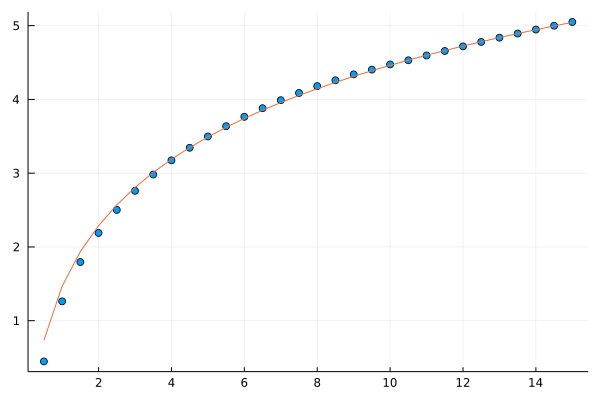

In [15]:
A=plot([i/2 for i in 1:30],Float64.(log.(Am))[1:30],seriestype = :scatter, legend = false)
function Y1(x)
    1.49486*log(sqrt(x*(x+1)))+0.949254
end
B=plot!([i/2 for i in 1:30],Y1)

In [10]:
data=DataFrame(X=(1:30)/2,Y=real.(float.(log.(Am)))[1:30])

,X,Y
,Float64,Float64
1,0.5,0.44794
2,1.0,1.26246
3,1.5,1.79556
4,2.0,2.18991
5,2.5,2.50242
6,3.0,2.76113
7,3.5,2.98182
8,4.0,3.17423
9,4.5,3.34477


In [22]:
exp.(data.Y) ./ (sqrt.(data.X.*(data.X.+1)) .^ (3/2))/exp(0.845291)

30-element Array{Float64,1}:
 0.8339435386678322
 0.9024090372480571
 0.9597807617796199
 1.000797410001788
 1.0307996914176978
 1.053541933249058
 1.0713285555508663
 1.0856029049142752
 1.0973043334940256
 1.1070673516735068
 1.1153342421716241
 1.12241885517743
 1.1282615170546504
 ⋮
 1.1126816759345044
 1.1095862123556879
 1.0941455790263677
 1.0921287196116476
 1.088658811822836
 1.090145909309203
 1.0915703349735248
 1.0931478171731894
 1.0946197575870216
 1.096005256967267
 1.0973015192519437
 1.0985171528364333

In [25]:
lm(@formula(Y~log(sqrt(X*(X+1)))),data[15:30,:])

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Array{Float64,1}},GLM.DensePredChol{Float64,CholeskyPivoted{Float64,Array{Float64,2}}}},Array{Float64,2}}

Y ~ 1 + :(log(sqrt(X * (X + 1))))

Coefficients:
───────────────────────────────────────────────────────────────────────────────────
                          Coef.  Std. Error       t  Pr(>|t|)  Lower 95%  Upper 95%
───────────────────────────────────────────────────────────────────────────────────
(Intercept)             1.09457   0.0259011   42.26    <1e-15    1.03901    1.15012
log(sqrt(X * (X + 1)))  1.43887   0.0105666  136.17    <1e-22    1.41621    1.46153
───────────────────────────────────────────────────────────────────────────────────

In [24]:
exp(1.09457)

2.9878976111498377

In [16]:
DataFrame(X=[1,2,3],Y=[1,2,3])

,X,Y
,Int64,Int64
1,1,1
2,2,2
3,3,3


In [8]:
float.([10.654777155143885 13.782091071055712 17.16939446255945 20.797831420730112 24.652196307892115 28.719869816937585 32.990151875243136 37.453815864027156 42.10279672540198 46.9299648827276 51.928957630189956 57.09405038404718])

1×12 Array{Float64,2}:
 10.6548  13.7821  17.1694  20.7978  …  42.1028  46.93  51.929  57.0941

In [80]:
al1=Fai4(jv2)

11×4 Array{Int64,2}:
 5   5  10  0
 5   6  10  0
 5   7  10  0
 5   8  10  0
 5   9  10  0
 5  10  10  0
 5  11  10  0
 5  12  10  0
 5  13  10  0
 5  14  10  0
 5  15  10  0

# 6 Valent Vertex

In [8]:
a=Fai6(jv1)
v123(jv1,a,1,2,3,6,jm61,jm62,B1,B2)

37×37 SparseMatrixCSC{Complex{Float64},Int64} with 44 stored entries:
  [12,  1]  =  15.1789+0.0im
  [13,  2]  =  15.1789+0.0im
  [14,  3]  =  15.1789+0.0im
  [15,  4]  =  20.7846-0.0im
  [16,  5]  =  20.7846-0.0im
  [17,  6]  =  20.7846-0.0im
  [18,  7]  =  20.7846+0.0im
  [19,  8]  =  20.7846+0.0im
  [20,  9]  =  20.7846+0.0im
  [24, 10]  =  11.3137-0.0im
  [25, 11]  =  11.3137-0.0im
  [1 , 12]  =  -15.1789+0.0im
  ⋮
  [10, 24]  =  -11.3137-0.0im
  [11, 25]  =  -11.3137-0.0im
  [12, 26]  =  -18.5903+0.0im
  [13, 27]  =  -18.5903+0.0im
  [14, 28]  =  -18.5903+0.0im
  [15, 29]  =  -24.0-0.0im
  [16, 30]  =  -24.0-0.0im
  [17, 31]  =  -24.0-0.0im
  [18, 32]  =  -26.533+0.0im
  [19, 33]  =  -26.533+0.0im
  [20, 34]  =  -26.533+0.0im
  [21, 35]  =  -24.0-0.0im
  [22, 36]  =  -24.0-0.0im

In [10]:
a=Fai6(1.5*jv1)
sum(abs.(imag.(v123(1.5*jv1,a,1,2,6,6))))

0.0

In [12]:
for i1 in 1:5
    for j1 in 1:5
        for k1 in 1:5
            jv2=[i1/2 j1/2 k1/2 i1/2 j1/2 k1/2]
            a=Fai6(jv2)
            vlist1=v123(jv2,a,1,2,3,6,jm61,jm62,B1,B2)+v123(jv2,a,1,2,4,6,jm61,jm62,B1,B2)+v123(jv2,a,1,2,5,6,jm61,jm62,B1,B2)+v123(jv2,a,1,2,6,6,jm61,jm62,B1,B2)
            vmax=0
            for i in 1:size(vlist1)[1]
                for j in 1:size(vlist1)[2]
                    if vmax <= abs(vlist1[i,j])
                        vmax = abs(vlist1[i,j])
                    end
                end
            end
            println("j=",jv2,"vmax=",vmax)
        end
    end
end

j=[0.5 0.5 0.5 0.5 0.5 0.5]vmax=4.440892098500626e-16
j=[0.5 0.5 1.0 0.5 0.5 1.0]vmax=4.440892098500626e-16
j=[0.5 0.5 1.5 0.5 0.5 1.5]vmax=4.440892098500626e-16
j=[0.5 0.5 2.0 0.5 0.5 2.0]vmax=4.440892098500626e-16
j=[0.5 0.5 2.5 0.5 0.5 2.5]vmax=8.881784197001252e-16
j=[0.5 1.0 0.5 0.5 1.0 0.5]vmax=6.661338147750939e-16
j=[0.5 1.0 1.0 0.5 1.0 1.0]vmax=2.220446049250313e-15
j=[0.5 1.0 1.5 0.5 1.0 1.5]vmax=1.7763568394002505e-15
j=[0.5 1.0 2.0 0.5 1.0 2.0]vmax=3.552713678800501e-15
j=[0.5 1.0 2.5 0.5 1.0 2.5]vmax=1.7763568394002505e-15
j=[0.5 1.5 0.5 0.5 1.5 0.5]vmax=1.5543122344752192e-15
j=[0.5 1.5 1.0 0.5 1.5 1.0]vmax=2.6645352591003757e-15
j=[0.5 1.5 1.5 0.5 1.5 1.5]vmax=1.7763568394002505e-15
j=[0.5 1.5 2.0 0.5 1.5 2.0]vmax=2.6645352591003757e-15
j=[0.5 1.5 2.5 0.5 1.5 2.5]vmax=3.552713678800501e-15
j=[0.5 2.0 0.5 0.5 2.0 0.5]vmax=1.1102230246251565e-15
j=[0.5 2.0 1.0 0.5 2.0 1.0]vmax=1.7763568394002505e-15
j=[0.5 2.0 1.5 0.5 2.0 1.5]vmax=2.6645352591003757e-15
j=[0.5 2.0 2.0 0.5 

In [15]:
for i1 in 1:7
    ja=i1/2
    a=Fai6(ja*jv1)
    vlist1=-v123(ja*jv1,a,1,2,3,6,jm61,jm62,B1,B2)+v123(ja*jv1,a,1,3,4,6,jm61,jm62,B1,B2)+v123(ja*jv1,a,1,3,5,6,jm61,jm62,B1,B2)+v123(ja*jv1,a,1,3,6,6,jm61,jm62,B1,B2)
    vmax=0
    for i in 1:size(vlist1)[1]
        for j in 1:size(vlist1)[2]
            if vmax <= abs(vlist1[i,j])
                vmax = abs(vlist1[i,j])
            end
        end
    end
    println("j=",ja*jv1,"vmax=",vmax)
end

j=[0.5 1.0 1.5 0.5 1.0 1.5]vmax=1.7763568394002505e-15
j=[1.0 2.0 3.0 1.0 2.0 3.0]vmax=1.4210854715202004e-14
j=[1.5 3.0 4.5 1.5 3.0 4.5]vmax=9.947598300641403e-14
j=[2.0 4.0 6.0 2.0 4.0 6.0]vmax=2.8421709430404007e-13
j=[2.5 5.0 7.5 2.5 5.0 7.5]vmax=5.684341886080801e-13
j=[3.0 6.0 9.0 3.0 6.0 9.0]vmax=1.6768808563938364e-12
j=[3.5 7.0 10.5 3.5 7.0 10.5]vmax=2.1032064978498966e-12


In [77]:
for i1 in 1:7
    ja=i1/2
    a=Fai6(ja*jv1)
    vlist1=v123(ja*jv1,a,1,2,3,6)+v123(ja*jv1,a,2,3,4,6)+v123(ja*jv1,a,2,3,5,6)+v123(ja*jv1,a,2,3,6,6)
    vmax=0
    for i in 1:size(vlist1)[1]
        for j in 1:size(vlist1)[2]
            if vmax <= abs(vlist1[i,j])
                vmax = abs(vlist1[i,j])
            end
        end
    end
    println("j=",ja*jv1,"vmax=",vmax)
end

j=[0.5 1.0 1.5 0.5 1.0 1.5]vmax=1.7763568394002505e-15
j=[1.0 2.0 3.0 1.0 2.0 3.0]vmax=1.4210854715202004e-14
j=[1.5 3.0 4.5 1.5 3.0 4.5]vmax=1.0658141036401503e-13
j=[2.0 4.0 6.0 2.0 4.0 6.0]vmax=2.7000623958883807e-13
j=[2.5 5.0 7.5 2.5 5.0 7.5]vmax=5.684341886080801e-13
j=[3.0 6.0 9.0 3.0 6.0 9.0]vmax=1.6200374375330284e-12
j=[3.5 7.0 10.5 3.5 7.0 10.5]vmax=2.1032064978498966e-12


In [14]:
for i1 in 1:7
    ja=i1/2
    a=Fai6(ja*jv1)
    vlist1=v123(ja*jv1,a,1,2,5,6)-v123(ja*jv1,a,1,3,5,6)-v123(ja*jv1,a,1,4,5,6)+v123(ja*jv1,a,1,5,6,6)
    vmax=0
    for i in 1:size(vlist1)[1]
        for j in 1:size(vlist1)[2]
            if vmax <= abs(vlist1[i,j])
                vmax = abs(vlist1[i,j])
            end
        end
    end
    println("j=",ja*jv1,"vmax=",vmax)
end

j=[0.5 1.0 1.5 0.5 1.0 1.5]vmax=8.881784197001252e-16
j=[1.0 2.0 3.0 1.0 2.0 3.0]vmax=1.0658141036401503e-14
j=[1.5 3.0 4.5 1.5 3.0 4.5]vmax=3.907985046680551e-14
j=[2.0 4.0 6.0 2.0 4.0 6.0]vmax=1.5631940186722204e-13
j=[2.5 5.0 7.5 2.5 5.0 7.5]vmax=3.126388037344441e-13
j=[3.0 6.0 9.0 3.0 6.0 9.0]vmax=7.958078640513122e-13
j=[3.5 7.0 10.5 3.5 7.0 10.5]vmax=1.4779288903810084e-12


In [15]:
for i1 in 1:5
    for j1 in 1:5
        for k1 in 1:5
            jv2=[i1/2 j1/2 k1/2 i1/2 j1/2 k1/2]
            a=Fai6(jv2)
            vlist1=v123(jv2,a,1,2,5,6)-v123(jv2,a,1,3,5,6)-v123(jv2,a,1,4,5,6)+v123(jv2,a,1,5,6,6)
            vmax=0
            for i in 1:size(vlist1)[1]
                for j in 1:size(vlist1)[2]
                    if vmax <= abs(vlist1[i,j])
                        vmax = abs(vlist1[i,j])
                    end
                end
            end
            println("j=",jv2,"vmax=",vmax)
        end
    end
end

j=[0.5 0.5 0.5 0.5 0.5 0.5]vmax=4.440892098500626e-16
j=[0.5 0.5 1.0 0.5 0.5 1.0]vmax=4.440892098500626e-16
j=[0.5 0.5 1.5 0.5 0.5 1.5]vmax=8.881784197001252e-16
j=[0.5 0.5 2.0 0.5 0.5 2.0]vmax=1.1102230246251565e-15
j=[0.5 0.5 2.5 0.5 0.5 2.5]vmax=2.6645352591003757e-15
j=[0.5 1.0 0.5 0.5 1.0 0.5]vmax=4.440892098500626e-16
j=[0.5 1.0 1.0 0.5 1.0 1.0]vmax=6.661338147750939e-16
j=[0.5 1.0 1.5 0.5 1.0 1.5]vmax=8.881784197001252e-16
j=[0.5 1.0 2.0 0.5 1.0 2.0]vmax=2.6645352591003757e-15
j=[0.5 1.0 2.5 0.5 1.0 2.5]vmax=2.6645352591003757e-15
j=[0.5 1.5 0.5 0.5 1.5 0.5]vmax=1.7763568394002505e-15
j=[0.5 1.5 1.0 0.5 1.5 1.0]vmax=2.6645352591003757e-15
j=[0.5 1.5 1.5 0.5 1.5 1.5]vmax=2.6645352591003757e-15
j=[0.5 1.5 2.0 0.5 1.5 2.0]vmax=4.440892098500626e-15
j=[0.5 1.5 2.5 0.5 1.5 2.5]vmax=7.993605777301127e-15
j=[0.5 2.0 0.5 0.5 2.0 0.5]vmax=8.881784197001252e-16
j=[0.5 2.0 1.0 0.5 2.0 1.0]vmax=1.7763568394002505e-15
j=[0.5 2.0 1.5 0.5 2.0 1.5]vmax=2.6645352591003757e-15
j=[0.5 2.0 2.0 0.5 

In [75]:
for i1 in 1:7
    ja=i1/2
    a=Fai6(ja*jv1)
    vlist1=-v123(ja*jv1,a,1,2,4,6)-v123(ja*jv1,a,2,3,4,6)+v123(ja*jv1,a,2,4,5,6)+v123(ja*jv1,a,2,4,6,6)
    vmax=0
    for i in 1:size(vlist1)[1]
        for j in 1:size(vlist1)[2]
            if vmax <= abs(vlist1[i,j])
                vmax = abs(vlist1[i,j])
            end
        end
    end
    println("j=",ja*jv1,"vmax=",vmax)
end

j=[0.5 1.0 1.5 0.5 1.0 1.5]vmax=1.7763568394002505e-15
j=[1.0 2.0 3.0 1.0 2.0 3.0]vmax=1.0658141036401503e-14
j=[1.5 3.0 4.5 1.5 3.0 4.5]vmax=2.842170943040401e-14
j=[2.0 4.0 6.0 2.0 4.0 6.0]vmax=1.7053025658242404e-13
j=[2.5 5.0 7.5 2.5 5.0 7.5]vmax=2.984279490192421e-13
j=[3.0 6.0 9.0 3.0 6.0 9.0]vmax=7.389644451905042e-13
j=[3.5 7.0 10.5 3.5 7.0 10.5]vmax=1.5631940186722204e-12


In [68]:
    ja=1.5
    a=Fai6(ja*jv1)
    vlist1=-v123(ja*jv1,a,1,2,4,6)-v123(ja*jv1,a,2,3,4,6)+v123(ja*jv1,a,2,4,5,6)+v123(ja*jv1,a,2,4,6,6)
    vmax=0
    for i in 1:size(vlist1)[1]
        for j in 1:size(vlist1)[2]
            if abs(vlist1[i,j])>=0.1
                println(a[i,:],a[j,:],vlist1[i,j])
            end
        end
    end
    vmax

0

In [72]:
for i1 in 1:7
    ja=i1/2
    a=Fai6(ja*jv1)
    vlist1=v123(ja*jv1,a,1,4,5,6)+v123(ja*jv1,a,2,4,5,6)+v123(ja*jv1,a,3,4,5,6)+v123(ja*jv1,a,4,5,6,6)
    vmax=0
    for i in 1:size(vlist1)[1]
        for j in 1:size(vlist1)[2]
            if vmax <= abs(vlist1[i,j])
                vmax = abs(vlist1[i,j])
            end
        end
    end
    println("j=",ja*jv1,"vmax=",vmax)
end

j=[0.5 1.0 1.5 0.5 1.0 1.5]vmax=1.3322676295501878e-15
j=[1.0 2.0 3.0 1.0 2.0 3.0]vmax=1.7763568394002505e-14
j=[1.5 3.0 4.5 1.5 3.0 4.5]vmax=3.552713678800501e-14
j=[2.0 4.0 6.0 2.0 4.0 6.0]vmax=1.1368683772161603e-13
j=[2.5 5.0 7.5 2.5 5.0 7.5]vmax=2.2737367544323206e-13
j=[3.0 6.0 9.0 3.0 6.0 9.0]vmax=5.684341886080801e-13
j=[3.5 7.0 10.5 3.5 7.0 10.5]vmax=1.0800249583553523e-12


In [22]:
for i1 in 1:7
    ja=i1/2
    a=Fai6(ja*jv1)
    vlist1=v123(ja*jv1,a,1,3,5,6,jm61,jm62,A1,A2)+v123(ja*jv1,a,2,3,5,6,jm61,jm62,A1,A2)-v123(ja*jv1,a,3,4,5,6,jm61,jm62,A1,A2)+v123(ja*jv1,a,3,5,6,6,jm61,jm62,A1,A2)
    vmax=0
    for i in 1:size(vlist1)[1]
        for j in 1:size(vlist1)[2]
            if vmax <= abs(vlist1[i,j])
                vmax = abs(vlist1[i,j])
            end
        end
    end
    println("j=",ja*jv1,"vmax=",vmax)
end

j=[0.5 1.0 1.5 0.5 1.0 1.5]vmax=1.7763568394002505e-15
j=[1.0 2.0 3.0 1.0 2.0 3.0]vmax=2.842170943040401e-14
j=[1.5 3.0 4.5 1.5 3.0 4.5]vmax=1.3500311979441904e-13
j=[2.0 4.0 6.0 2.0 4.0 6.0]vmax=4.263256414560601e-13
j=[2.5 5.0 7.5 2.5 5.0 7.5]vmax=1.0800249583553523e-12
j=[3.0 6.0 9.0 3.0 6.0 9.0]vmax=1.9326762412674725e-12
j=[3.5 7.0 10.5 3.5 7.0 10.5]vmax=5.002220859751105e-12


# 4 Valent Vertex

In [27]:
qa(jv2)

11×11 Array{Float64,2}:
  0.0    -69.282     0.0       0.0    …     0.0       0.0       0.0
 69.282    0.0    -120.837     0.0          0.0       0.0       0.0
  0.0    120.837     0.0    -170.383        0.0       0.0       0.0
  0.0      0.0     170.383     0.0          0.0       0.0       0.0
  0.0      0.0       0.0     211.66         0.0       0.0       0.0
  0.0      0.0       0.0       0.0    …     0.0       0.0       0.0
  0.0      0.0       0.0       0.0          0.0       0.0       0.0
  0.0      0.0       0.0       0.0       -228.447     0.0       0.0
  0.0      0.0       0.0       0.0          0.0    -180.278     0.0
  0.0      0.0       0.0       0.0        180.278     0.0    -105.131
  0.0      0.0       0.0       0.0    …     0.0     105.131     0.0

In [26]:
a=Fai4(jv2)
v123(jv2,a,1,2,3,4,jm61,jm62,B1,B2)

11×11 SparseMatrixCSC{Complex{Float64},Int64} with 20 stored entries:
  [2 ,  1]  =  69.282-0.0im
  [1 ,  2]  =  -69.282+0.0im
  [3 ,  2]  =  120.837-0.0im
  [2 ,  3]  =  -120.837+0.0im
  [4 ,  3]  =  170.383-0.0im
  [3 ,  4]  =  -170.383+0.0im
  [5 ,  4]  =  211.66-0.0im
  [4 ,  5]  =  -211.66+0.0im
  [6 ,  5]  =  241.209-0.0im
  [5 ,  6]  =  -241.209+0.0im
  [7 ,  6]  =  255.89-0.0im
  [6 ,  7]  =  -255.89+0.0im
  [8 ,  7]  =  252.645-0.0im
  [7 ,  8]  =  -252.645+0.0im
  [9 ,  8]  =  228.447-0.0im
  [8 ,  9]  =  -228.447+0.0im
  [10,  9]  =  180.278-0.0im
  [9 , 10]  =  -180.278+0.0im
  [11, 10]  =  105.131-0.0im
  [10, 11]  =  -105.131+0.0im

In [19]:
a=Fai4(jv2)
v123(jv2,a,1,3,4,4,jm61,jm62,A1,A2)

11×11 Array{Complex{Float64},2}:
    0.0+0.0im  -69.282+0.0im  …       0.0+0.0im       0.0+0.0im
 69.282+0.0im      0.0+0.0im          0.0+0.0im       0.0+0.0im
    0.0+0.0im  120.837+0.0im          0.0+0.0im       0.0+0.0im
    0.0+0.0im      0.0+0.0im          0.0+0.0im       0.0+0.0im
    0.0+0.0im      0.0+0.0im          0.0+0.0im       0.0+0.0im
    0.0+0.0im      0.0+0.0im  …       0.0+0.0im       0.0+0.0im
    0.0+0.0im      0.0+0.0im          0.0+0.0im       0.0+0.0im
    0.0+0.0im      0.0+0.0im          0.0+0.0im       0.0+0.0im
    0.0+0.0im      0.0+0.0im     -180.278+0.0im       0.0+0.0im
    0.0+0.0im      0.0+0.0im          0.0+0.0im  -105.131+0.0im
    0.0+0.0im      0.0+0.0im  …   105.131-0.0im       0.0+0.0im

In [20]:
a=Fai4(jv2)
v123(jv2,a,1,2,4,4,jm61,jm62,A1,A2)

11×11 Array{Complex{Float64},2}:
     0.0+0.0im    69.282-0.0im  …       0.0-0.0im     -0.0+0.0im
 -69.282-0.0im       0.0+0.0im         -0.0+0.0im      0.0-0.0im
    -0.0-0.0im  -120.837-0.0im          0.0-0.0im     -0.0+0.0im
    -0.0-0.0im      -0.0-0.0im         -0.0+0.0im      0.0-0.0im
    -0.0-0.0im      -0.0-0.0im          0.0-0.0im     -0.0+0.0im
    -0.0-0.0im      -0.0-0.0im  …      -0.0+0.0im      0.0-0.0im
    -0.0-0.0im      -0.0-0.0im          0.0-0.0im     -0.0+0.0im
    -0.0-0.0im      -0.0-0.0im         -0.0+0.0im      0.0-0.0im
    -0.0-0.0im      -0.0-0.0im      180.278-0.0im     -0.0+0.0im
    -0.0-0.0im      -0.0-0.0im          0.0+0.0im  105.131-0.0im
    -0.0-0.0im      -0.0-0.0im  …  -105.131-0.0im      0.0+0.0im

In [21]:
a=Fai4(jv2)
v123(jv2,a,2,3,4,4,jm61,jm62,A1,A2)

11×11 Array{Complex{Float64},2}:
     0.0+0.0im    69.282+0.0im  …       0.0+0.0im      0.0+0.0im
 -69.282+0.0im       0.0+0.0im          0.0+0.0im      0.0+0.0im
     0.0+0.0im  -120.837-0.0im          0.0+0.0im      0.0+0.0im
     0.0+0.0im       0.0+0.0im          0.0+0.0im      0.0+0.0im
     0.0+0.0im       0.0+0.0im          0.0+0.0im      0.0+0.0im
     0.0+0.0im       0.0+0.0im  …       0.0+0.0im      0.0+0.0im
     0.0+0.0im       0.0+0.0im          0.0+0.0im      0.0+0.0im
     0.0+0.0im       0.0+0.0im          0.0+0.0im      0.0+0.0im
     0.0+0.0im       0.0+0.0im      180.278+0.0im      0.0+0.0im
     0.0+0.0im       0.0+0.0im          0.0+0.0im  105.131+0.0im
     0.0+0.0im       0.0+0.0im  …  -105.131+0.0im      0.0+0.0im

In [5]:
@btime testv(jv1,al1,2,3,4)

  248.011 ms (3801888 allocations: 165.84 MiB)


In [ ]:
for i in 0:20
    for j in 0:20
        for k in 0:20
            jv1=[i i j j k k]
            al1=Fai6(jv1)
            testv(jv1,al1,2,3,4)
        end
        print("j=",j)
    end
    print("i=",i)
end

j=0j=1j=2j=3j=4j=5j=6j=7j=8j=9j=10j=11j=12j=13j=14j=15j=16j=17j=18j=19j=20i=0j=0j=1j=2j=3j=4j=5j=6j=7j=8j=9j=10j=11j=12j=13j=14j=15j=16j=17j=18j=19j=20i=1j=0j=1j=2j=3j=4j=5j=6j=7j=8j=9j=10j=11j=12j=13j=14j=15j=16j=17j=18j=19j=20i=2j=0j=1j=2j=3j=4j=5j=6j=7j=8j=9j=10j=11j=12j=13j=14j=15j=16j=17j=18j=19j=20i=3j=0j=1j=2j=3j=4j=5j=6j=7j=8j=9j=10j=11j=12j=13j=14j=15j=16j=17j=18j=19j=20i=4j=0j=1j=2j=3j=4j=5j=6j=7j=8j=9j=10